# **Mutant Moneynall Project**

### **Importing the Dataset**

In [139]:
# Importing the __ I think will be useful in this project. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading in the dataset
df = pd.read_csv("mutant_moneyball.csv")

# Checking to make sure the dataset loaded
df.head()


,Member,TotalValue60s_heritage,TotalValue70s_heritage,TotalValue80s_heritage,TotalValue90s_heritage,TotalValue60s_ebay,TotalValue70s_ebay,TotalValue80s_ebay,TotalValue90s_ebay,TotalValue60s_wiz,TotalValue70s_wiz,TotalValue80s_wiz,TotalValue90s_wiz,TotalValue60s_oStreet,TotalValue70s_oStreet,TotalValue80s_oStreet,TotalValue90s_oStreet
0,warrenWorthington,929056.0,154585.0,23957.0,960.0,23335.0,3362.0,583.0,97.0,"$7,913.00","$1,105.00",$226.00,$65.75,"$68,160.00","$7,360.00",$975.00,$123.00
1,hankMcCoy,929776.0,20705.0,6631.0,881.0,23377.0,1224.0,289.0,82.0,"$7,953.00",$851.00,$89.00,$38.50,"$68,390.00","$5,260.00",$431.00,$81.00
2,scottSummers,933616.0,188635.0,29240.0,739.0,23420.0,5431.0,1031.0,82.0,"$7,993.00","$1,979.00",$438.00,$39.25,"$68,590.00","$11,675.00","$1,427.00",$74.00
3,bobbyDrake,929776.0,154585.0,1514.0,874.0,23377.0,3362.0,70.0,93.0,"$7,953.00","$1,105.00",$48.00,$62.00,"$68,390.00","$7,360.00",$137.00,$108.00
4,jeanGrey,933616.0,179899.0,16868.0,1708.0,23420.0,4903.0,665.0,170.0,"$7,993.00","$1,679.00",$165.00,$108.00,"$68,590.00","$10,265.00",$822.00,$189.00


### **Data Cleaning and Tidy Process**

In [140]:
# Converting the data from wide format to long format using .melt()
df_tidy = df.melt(
    id_vars = "Member",
    var_name = "Variable",
    value_name = "Value"
)

# Checking the new format
df_tidy.head()

,Member,Variable,Value
0,warrenWorthington,TotalValue60s_heritage,929056.0
1,hankMcCoy,TotalValue60s_heritage,929776.0
2,scottSummers,TotalValue60s_heritage,933616.0
3,bobbyDrake,TotalValue60s_heritage,929776.0
4,jeanGrey,TotalValue60s_heritage,933616.0


In [141]:
# There are still multiple values within the Variable comlumn, whihc need to be split 
df_tidy[['Decade', 'Source']] = df_tidy['Variable'].str.split("_", expand = True)

# Checking the new format
df_tidy.head()

,Member,Variable,Value,Decade,Source
0,warrenWorthington,TotalValue60s_heritage,929056.0,TotalValue60s,heritage
1,hankMcCoy,TotalValue60s_heritage,929776.0,TotalValue60s,heritage
2,scottSummers,TotalValue60s_heritage,933616.0,TotalValue60s,heritage
3,bobbyDrake,TotalValue60s_heritage,929776.0,TotalValue60s,heritage
4,jeanGrey,TotalValue60s_heritage,933616.0,TotalValue60s,heritage


In [142]:
# Need to clean the Decade Column by removing the "TotalValue" portion
df_tidy['Decade'] = df_tidy['Decade'].str.replace('TotalValue','')

# Checking the new format
df_tidy.head()

,Member,Variable,Value,Decade,Source
0,warrenWorthington,TotalValue60s_heritage,929056.0,60s,heritage
1,hankMcCoy,TotalValue60s_heritage,929776.0,60s,heritage
2,scottSummers,TotalValue60s_heritage,933616.0,60s,heritage
3,bobbyDrake,TotalValue60s_heritage,929776.0,60s,heritage
4,jeanGrey,TotalValue60s_heritage,933616.0,60s,heritage


In [ ]:
# How do I split the names? Some have dollar signs, some dont, how do I fix?

# Is there more I should clean? 

df_tidy["Member"] = (
    df_tidy["Member"]
    .str.replace(r'([a-z])([A-Z])', r'\1 \2', regex=True)  # add spaces
    .str.replace("Mc ", "Mc", regex=False)                 # fix McCoy issue
    .str.title()                                           # capitalize names
)

# first time i did above it showed a weird space in McCoy, was that jsut lucky it was in top 5? hwo do i know if its splitting other names? 

df_tidy['Value'] = (
    df_tidy['Value']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)   # remove $ and commas
    .str.strip()                             # remove extra spaces
)

df_tidy['Value'] = pd.to_numeric(df_tidy['Value'], errors='coerce')

# Cheack formatting 
df_tidy.head()

,Member,Variable,Value,Decade,Source
0,Warren Worthington,TotalValue60s_heritage,929056.0,60s,heritage
1,Hank Mccoy,TotalValue60s_heritage,929776.0,60s,heritage
2,Scott Summers,TotalValue60s_heritage,933616.0,60s,heritage
3,Bobby Drake,TotalValue60s_heritage,929776.0,60s,heritage
4,Jean Grey,TotalValue60s_heritage,933616.0,60s,heritage


In [144]:
# Keep only the clean columns 
df2_tidy = df_tidy[['Member','Decade','Source','Value']]
df2_tidy.head()

,Member,Decade,Source,Value
0,Warren Worthington,60s,heritage,929056.0
1,Hank Mccoy,60s,heritage,929776.0
2,Scott Summers,60s,heritage,933616.0
3,Bobby Drake,60s,heritage,929776.0
4,Jean Grey,60s,heritage,933616.0


### **Visualizations**

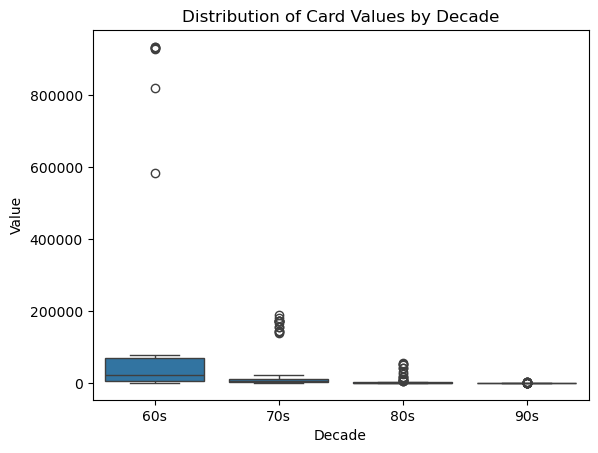

In [145]:
# Is there a way to make this better?

# Boxplot to show the overall distribution by decade 
plt.figure()

sns.boxplot(
    data=df_tidy,
    x="Decade",
    y="Value"
)

plt.title("Distribution of Card Values by Decade")
plt.show()

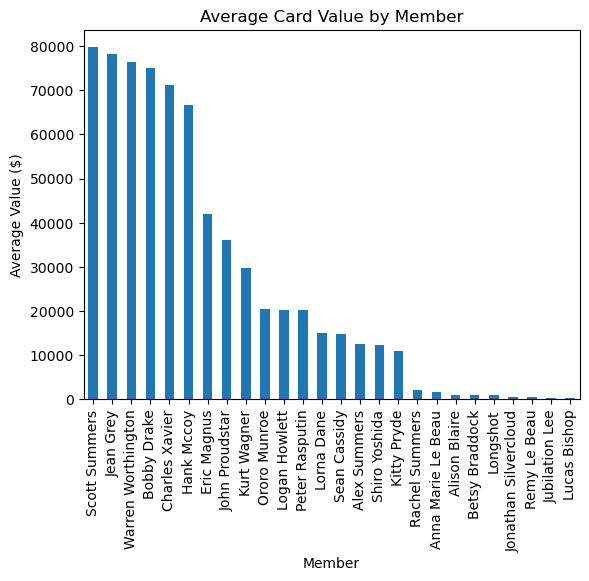

In [146]:
# Bar chart for average card value fro each member, signifies most valuable characetrs, consisitently valuable characters, and ranks characters by average value 
avg_values = (
    df2_tidy.groupby("Member")["Value"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()

avg_values.plot(kind="bar")

plt.title("Average Card Value by Member")
plt.ylabel("Average Value ($)")
plt.xticks(rotation=90)

plt.show()

#Shoudl I just od top 10? How do I do that?

### **Pivot Table**

In [ ]:
# Demonstrate that each memebr has multiple values 
df2_tidy.groupby("Member")["Value"].count()

Member
Alex Summers            16
Alison Blaire            8
Anna Marie Le Beau       8
Betsy Braddock           8
Bobby Drake             16
Charles Xavier          16
Eric Magnus             16
Hank Mccoy              16
Jean Grey               16
John Proudstar           4
Jonathan Silvercloud     8
Jubilation Lee           8
Kitty Pryde              4
Kurt Wagner              8
Logan Howlett           12
Longshot                 4
Lorna Dane              16
Lucas Bishop             4
Ororo Munroe            12
Peter Rasputin          12
Rachel Summers           8
Remy Le Beau             4
Scott Summers           16
Sean Cassidy            16
Shiro Yoshida           12
Warren Worthington      16
Name: Value, dtype: int64

In [ ]:
# Show the maximum value for each member 
pivot_table = df2_tidy.pivot_table(
    values="Value",
    index="Member",
    aggfunc="max"
)

pivot_table

,Value
Member,
Alex Summers,144946.0
Alison Blaire,7198.0
Anna Marie Le Beau,10730.0
Betsy Braddock,5573.0
Bobby Drake,929776.0
Charles Xavier,819537.0
Eric Magnus,582934.0
Hank Mccoy,929776.0
Jean Grey,933616.0
